In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean dataset
df = pd.read_csv('../outputs/secom_clean.csv')
labels = pd.read_csv('../outputs/secom_labels_clean.csv')

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Labels: {labels.shape[0]} rows")

Loaded: 1567 rows x 562 columns
Labels: 1567 rows


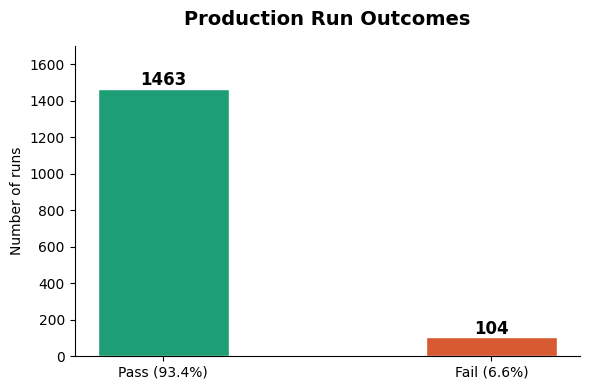

Chart saved.


In [2]:
# Chart 1: Pass/Fail distribution
fig, ax = plt.subplots(figsize=(6, 4))

outcome_labels = ['Pass (93.4%)', 'Fail (6.6%)']
outcome_values = [1463, 104]
colors = ['#1D9E75', '#D85A30']

bars = ax.bar(outcome_labels, outcome_values, color=colors, width=0.4, edgecolor='white')

ax.set_title('Production Run Outcomes', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of runs')
ax.set_ylim(0, 1700)

for bar, val in zip(bars, outcome_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', fontsize=12, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/01_pass_fail_distribution.png', dpi=150)
plt.show()
print("Chart saved.")

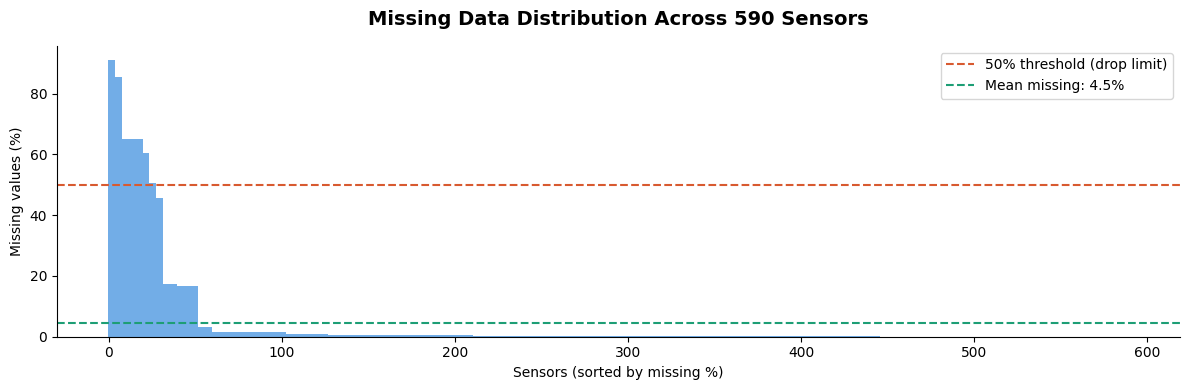

Chart saved.


In [4]:
# Chart 2: Missing data pattern across sensors
df_raw = pd.read_csv('../data/secom.data', sep=' ', header=None)

missing_pct = df_raw.isnull().mean() * 100
missing_pct_sorted = missing_pct.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(range(len(missing_pct_sorted)),
       missing_pct_sorted.values,
       color='#378ADD',
       width=1.0,
       edgecolor='none',
       alpha=0.7)

ax.axhline(y=50, color='#D85A30', linestyle='--', linewidth=1.5, label='50% threshold (drop limit)')
mean_missing = missing_pct_sorted.mean()
ax.axhline(y=mean_missing, color='#1D9E75', linestyle='--', linewidth=1.5, label='Mean missing: ' + str(round(mean_missing, 1)) + '%')

ax.set_title('Missing Data Distribution Across 590 Sensors', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sensors (sorted by missing %)')
ax.set_ylabel('Missing values (%)')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/02_missing_data_pattern.png', dpi=150)
plt.show()
print("Chart saved.")

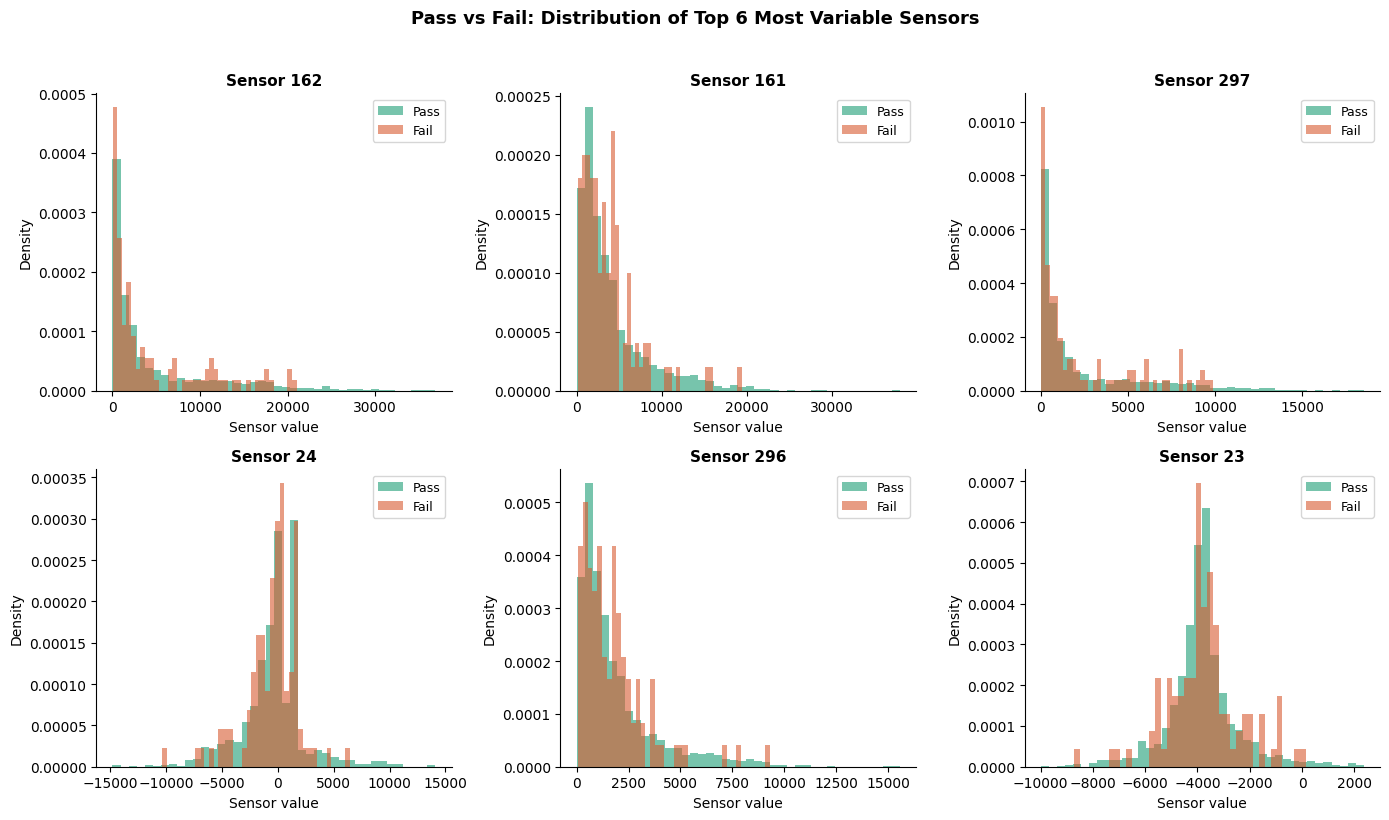

Chart saved.


In [5]:
# Chart 3: Top 6 most variable sensors — pass vs fail comparison
df['outcome'] = labels['outcome'].values

# Find the 6 sensors with highest variance — most informative
top_sensors = df.drop('outcome', axis=1).var().nlargest(6).index

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    pass_data = df[df['outcome'] == -1][sensor]
    fail_data = df[df['outcome'] == 1][sensor]
    
    axes[i].hist(pass_data, bins=40, alpha=0.6, color='#1D9E75', label='Pass', density=True)
    axes[i].hist(fail_data, bins=40, alpha=0.6, color='#D85A30', label='Fail', density=True)
    axes[i].set_title('Sensor ' + str(sensor), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Sensor value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Pass vs Fail: Distribution of Top 6 Most Variable Sensors', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")